Analía Olivero Betancor

# Capítulo 2: fundamentos algebraicos y criptográficos

Este cuaderno recopila los códigos utilizados para generar las figuras incluidas en el capítulo dedicado a los fundamentos algebraicos y criptográficos. El objetivo es ilustrar visualmente algunos de los conceptos matemáticos empleados posteriormente en la construcción de los protocolos criptográficos estudiados.

## 2.2. Curva de Edwards Retorcidas

En el ejemplo $2.10$ se calculan los puntos de la curva

$$
-x^2+y^2 \equiv 1+3x^2y^2 \pmod{17}.
$$

Aunque en el texto se muestran algunos cálculos manuales utilizando el símbolo de Legendre, para obtener el conjunto completo de puntos resulta más cómodo realizar una búsqueda exhaustiva sobre todos los pares $(x,y)\in\mathbb{F}_{17}^2$.

El siguiente código recorre todas las posibles coordenadas y comprueba directamente si satisfacen la ecuación de la curva. Posteriormente se representan gráficamente los puntos obtenidos.

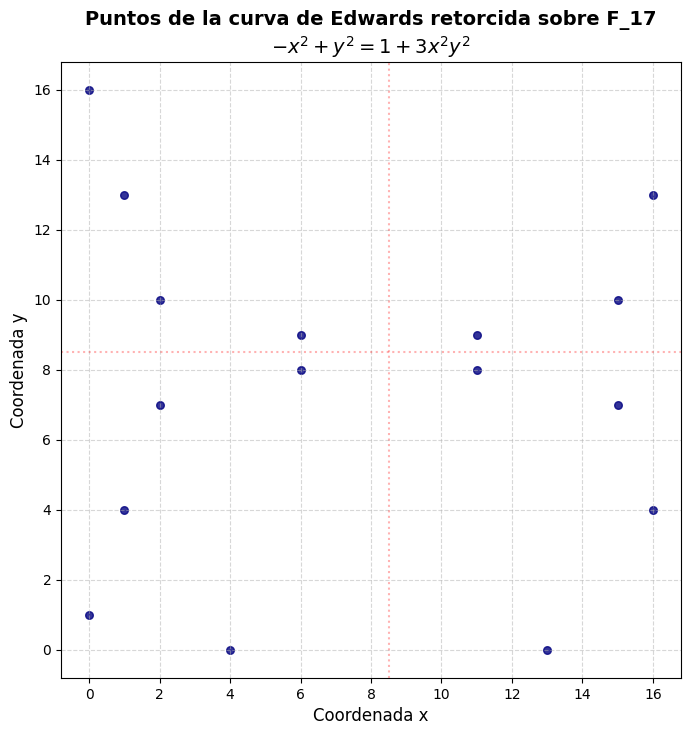

In [1]:
import matplotlib.pyplot as plt

# Parámetros de la curva
p = 17
a = -1
d = 3

puntos_x = []
puntos_y = []

# Búsqueda evaluando todos los pares (x,y)
for x in range(p):
    for y in range(p):
        
        # Comprobamos la ecuación -x^2 + y^2 = 1 + 3*x^2*y^2 (mod 17)
        izq = (a * x**2 + y**2) % p
        der = (1 + d * x**2 * y**2) % p
        
        if izq == der:
            puntos_x.append(x)
            puntos_y.append(y)

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.scatter(puntos_x, puntos_y, color='navy', s=30, alpha=0.8)

plt.title('Puntos de la curva de Edwards retorcida sobre F_17\n$-x^2 + y^2 = 1 + 3x^2y^2$', fontsize=14, fontweight='bold')
plt.xlabel(f'Coordenada x', fontsize=12)
plt.ylabel(f'Coordenada y', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(p/2, color='red', linestyle=':', alpha=0.3)
plt.axvline(p/2, color='red', linestyle=':', alpha=0.3)

plt.show()

En el ejemplo $2.12$ se comprueba la suma de dos puntos en la curva de Edwards retorcida empleando la ley de grupo. Tomando $P_1 = (1,4)$ y $P_2 = (4,0)$, se obtiene el punto resultante $P_3 = (16,4)$.

Aprovechando que ya tenemos las coordenadas de todos los puntos, el siguiente código los grafica en segundo plano y destaca el elemento neutro $\mathcal{O}_\infty$, los dos puntos iniciales y el resultado de la suma para visualizar gráficamente la operación.

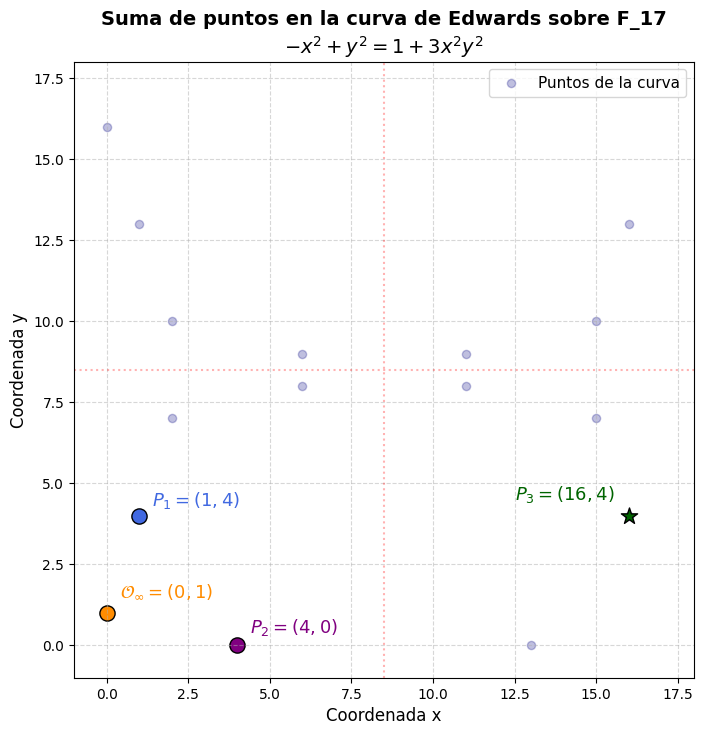

In [2]:
x1, y1 = 1, 4
x2, y2 = 4, 0
x_O, y_O = 0, 1

# Calculamos P3 = P1 + P2 con las fórmulas de la ley de grupo
num_x = (x1 * y2 + y1 * x2) % p
den_x = (1 + d * x1 * x2 * y1 * y2) % p
x3 = (num_x * pow(den_x, -1, p)) % p # pow(base, -1, p) nos da el inverso en F_p

num_y = (y1 * y2 - a * x1 * x2) % p
den_y = (1 - d * x1 * x2 * y1 * y2) % p
y3 = (num_y * pow(den_y, -1, p)) % p

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.scatter(puntos_x, puntos_y, color='navy', s=35, alpha=0.25, label='Puntos de la curva')

# Elemento neutro
plt.scatter(x_O, y_O, color='darkorange', s=120, edgecolors='black')
plt.text(x_O + 0.4, y_O + 0.5, r'$\mathcal{O}_\infty = (0,1)$', fontsize=13, color='darkorange', fontweight='bold')

# P1
plt.scatter(x1, y1, color='royalblue', s=120, edgecolors='black')
plt.text(x1 + 0.4, y1 + 0.3, f'$P_1 = ({x1}, {y1})$', fontsize=13, color='royalblue', fontweight='bold')

# P2
plt.scatter(x2, y2, color='purple', s=120, edgecolors='black')
plt.text(x2 + 0.4, y2 + 0.4, f'$P_2 = ({x2}, {y2})$', fontsize=13, color='purple', fontweight='bold')

# P3
plt.scatter(x3, y3, color='darkgreen', s=150, edgecolors='black', marker='*')
plt.text(x3 - 3.5, y3 + 0.5, f'$P_3 = ({x3}, {y3})$', fontsize=13, color='darkgreen', fontweight='bold')

plt.title('Suma de puntos en la curva de Edwards sobre F_17\n$-x^2 + y^2 = 1 + 3x^2y^2$', fontsize=14, fontweight='bold')
plt.xlabel(f'Coordenada x', fontsize=12)
plt.ylabel(f'Coordenada y', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(p/2, color='red', linestyle=':', alpha=0.3)
plt.axvline(p/2, color='red', linestyle=':', alpha=0.3)

plt.xlim(-1, 18)
plt.ylim(-1, 18)
plt.legend(loc='upper right', fontsize=11)

plt.show()

## 2.2.1 Análisis y Comparación: Weierstrass vs. Edwards

### El modelo continuo: El problema del infinito

Para ilustrar el comportamiento de la curva en Monero, comenzamos analizando el modelo continuo sobre los números reales ($\mathbb{R}$). Tomamos como referencia la curva de Weierstrass $y^2 = x^3 - 3x + 3$.

El siguiente código dibuja esta curva y aplica geométricamente el método de la cuerda y la tangente para sumar dos puntos $P$ y $Q$. Trazamos la recta secante, encontramos la tercera intersección $-R$, y la reflejamos sobre el eje $x$ para obtener el punto resultante $R = P + Q$.

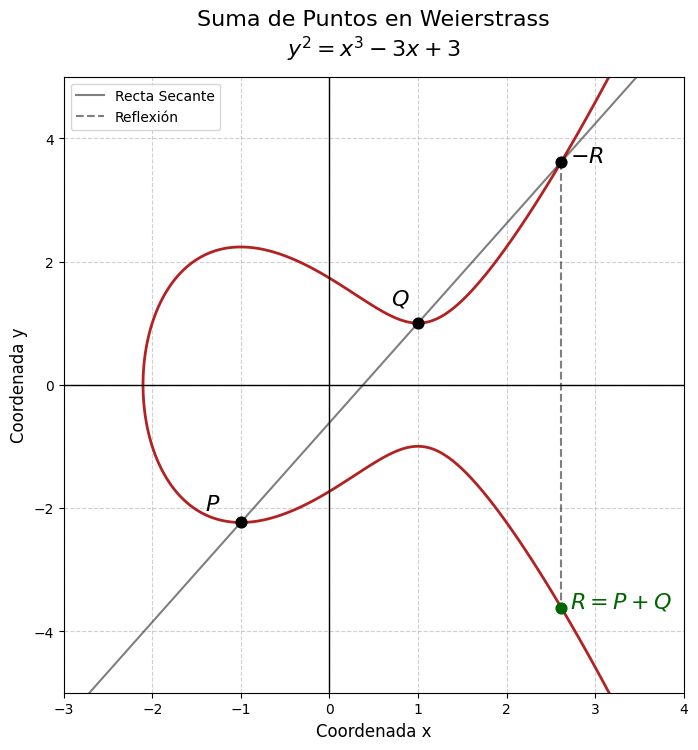

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la curva
a_w, b_w = -3, 3

y, x = np.ogrid[-6:6:400j, -4:5:400j]
curva_weierstrass = y**2 - x**3 - a_w*x - b_w

# Definición de P y Q en la curva (ajustados para que el corte sea visible)
P_x = -1.0
P_y = -np.sqrt(P_x**3 + a_w*P_x + b_w) 

Q_x = 1.0
Q_y = np.sqrt(Q_x**3 + a_w*Q_x + b_w)  

# Cálculo de la pendiente de la recta secante (m)
m = (Q_y - P_y) / (Q_x - P_x)

# Cálculo de la intersección (-R) y el punto final de la suma (R)
R_inter_x = m**2 - P_x - Q_x
R_inter_y = P_y + m * (R_inter_x - P_x)
R_suma_y = -R_inter_y # Reflexión sobre el eje X

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.contour(x.ravel(), y.ravel(), curva_weierstrass, [0], colors='firebrick', linewidths=2)

x_line = np.linspace(-3, 4, 100)
y_line = m * (x_line - P_x) + P_y
plt.plot(x_line, y_line, 'k-', alpha=0.5, label='Recta Secante')
plt.plot([R_inter_x, R_inter_x], [R_inter_y, R_suma_y], 'k--', alpha=0.5, label='Reflexión')

plt.scatter([P_x, Q_x, R_inter_x], [P_y, Q_y, R_inter_y], color='black', s=60, zorder=5)
plt.scatter([R_inter_x], [R_suma_y], color='darkgreen', s=60, zorder=5)
plt.text(P_x - 0.4, P_y + 0.2, '$P$', fontsize=16, fontweight='bold')
plt.text(Q_x - 0.3, Q_y + 0.3, '$Q$', fontsize=16, fontweight='bold')
plt.text(R_inter_x + 0.1, R_inter_y, '$-R$', fontsize=16, fontweight='bold')
plt.text(R_inter_x + 0.1, R_suma_y, '$R = P+Q$', fontsize=16, fontweight='bold', color='darkgreen')

plt.title('Suma de Puntos en Weierstrass\n$y^2 = x^3 - 3x + 3$', fontsize=16, pad=15)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(-3, 4)
plt.ylim(-5, 5)
plt.xlabel('Coordenada x', fontsize=12)
plt.ylabel('Coordenada y', fontsize=12)
plt.legend()

plt.show()

Para continuar con la comparativa, el siguiente código ilustra gráficamente el conflicto que surge al intentar sumar un punto con su inverso, $P + (-P)$, en el modelo continuo de Weierstrass. 

Al trazar la recta secante que une ambos puntos, obtenemos una línea vertical. Al tratarse de una curva abierta en el plano afín, esta recta no vuelve a intersecar la ecuación en un tercer punto, lo que justifica la necesidad de añadir el punto del infinito ($\mathcal{O}_\infty$).

<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/00/kc8_6sfn643c8dzts0h1c6gc0000gn/T/ipykernel_5501/1465131537.py:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title('Curva de Weierstrass sobre $\mathbb{R}$ \n $y^2 = x^3 - 3x + 3$', fontsize=16, pad=15)


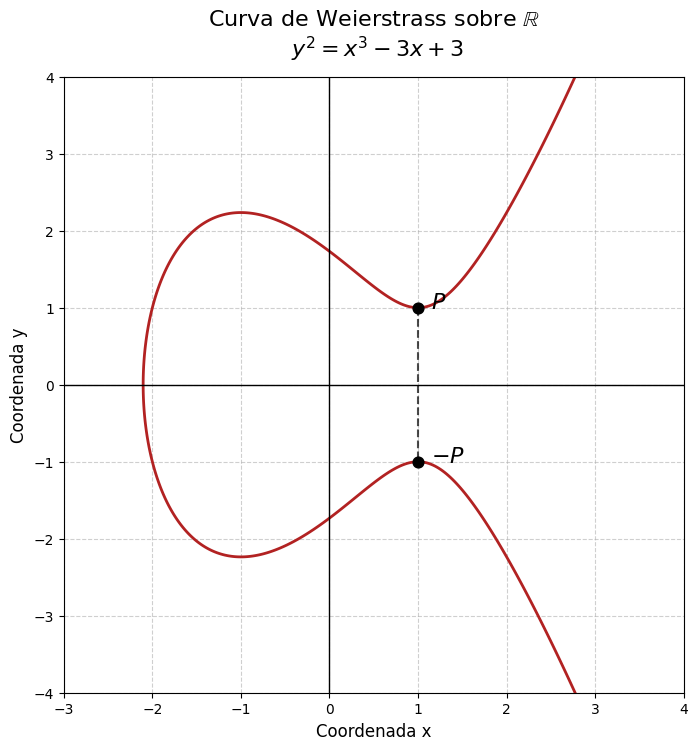

In [4]:
# Coordenadas del punto P y su inverso -P
x_P = 1.0
y_P = np.sqrt(x_P**3 + a_w*x_P + b_w)

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.contour(x.ravel(), y.ravel(), curva_weierstrass, [0], colors='firebrick', linewidths=2)

plt.plot([x_P, x_P], [y_P, -y_P], 'k--', alpha=0.7, linewidth=1.5)

plt.scatter([x_P, x_P], [y_P, -y_P], color='black', s=60, zorder=5)
plt.text(x_P + 0.15, y_P, '$P$', fontsize=16, fontweight='bold')
plt.text(x_P + 0.15, -y_P, '$-P$', fontsize=16, fontweight='bold')

plt.title('Curva de Weierstrass sobre $\mathbb{R}$ \n $y^2 = x^3 - 3x + 3$', fontsize=16, pad=15)
plt.xlabel('Coordenada x', fontsize=12)
plt.ylabel('Coordenada y', fontsize=12)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(-3, 4)
plt.ylim(-4, 4)

plt.show()

Para solucionar el problema de completitud que presenta Weierstrass, las curvas de Edwards retorcidas sustituyen la recta secante por una hipérbola auxiliar. Obligamos a esta hipérbola a pasar por un anclaje fijo (el polo $(0,-1)$) y por los dos puntos que queremos sumar ($P$ y $Q$).

El siguiente código resuelve el sistema de ecuaciones lineales para hallar los coeficientes de la hipérbola $xy + px + q(y+1) = 0$. Tras graficar su intersección con la curva continua sobre $\mathbb{R}$, encontramos un cuarto punto de corte ($-R$). Al reflejar este punto respecto al eje $y$, obtenemos el resultado definitivo de la operación: $R = P + Q$.

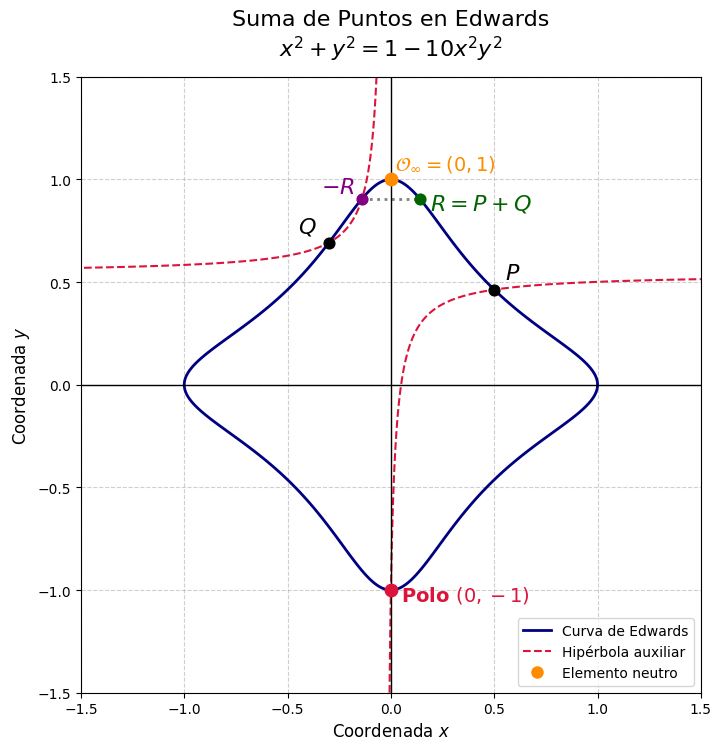

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Parámetro de la curva de Edwards
d = -10

y_e, x_e = np.ogrid[-1.5:1.5:400j, -1.5:1.5:400j]
curva_edwards = x_e**2 + y_e**2 - 1 - d*(x_e**2)*(y_e**2)

# Coordenadas de P y Q
x_P = 0.5
y_P = np.sqrt((1 - x_P**2) / (1 - d*x_P**2)) 

x_Q = -0.3
y_Q = np.sqrt((1 - x_Q**2) / (1 - d*x_Q**2)) 

# Cálculo de R = P + Q
den_x = 1 + d * x_P * x_Q * y_P * y_Q
den_y = 1 - d * x_P * x_Q * y_P * y_Q
x_R = (x_P * y_Q + y_P * x_Q) / den_x
y_R = (y_P * y_Q - x_P * x_Q) / den_y

# Construcción de la hipérbola auxiliar
A = np.array([[x_P, y_P + 1],
              [x_Q, y_Q + 1]])
B = np.array([-x_P * y_P, -x_Q * y_Q])
p, q = np.linalg.solve(A, B)

# Evaluación de la hipérbola
curva_hiperbola = x_e*y_e + p*x_e + q*(y_e + 1)

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.contour(x_e.ravel(), y_e.ravel(), curva_edwards, [0], colors='navy', linewidths=2)
plt.contour(x_e.ravel(), y_e.ravel(), curva_hiperbola, [0], colors='crimson', linestyles='dashed', linewidths=1.5)

# Punto de anclaje
plt.scatter([0], [-1], color='crimson', s=80, zorder=5)
plt.text(0.05, -1.05, 'Polo $(0,-1)$', fontsize=14, color='crimson', fontweight='bold')

# Elemento neutro
plt.scatter([0], [1], color='darkorange', s=80, zorder=5)
plt.text(0.02, 1.05, r'$\mathcal{O}_\infty = (0,1)$', fontsize=14, color='darkorange', fontweight='bold')

# P y Q
plt.scatter([x_P, x_Q], [y_P, y_Q], color='black', s=60, zorder=5)
plt.text(x_P + 0.05, y_P + 0.05, '$P$', fontsize=16, fontweight='bold')
plt.text(x_Q - 0.15, y_Q + 0.05, '$Q$', fontsize=16, fontweight='bold')

# -R
x_R_neg = -x_R 
plt.scatter([x_R_neg], [y_R], color='purple', s=60, zorder=5)
plt.text(x_R_neg - 0.20, y_R + 0.03, '$-R$', fontsize=16, fontweight='bold', color='purple')

# R
plt.scatter([x_R], [y_R], color='darkgreen', s=60, zorder=5)
plt.text(x_R + 0.05, y_R - 0.05, '$R = P+Q$', fontsize=16, fontweight='bold', color='darkgreen')

plt.plot([x_R_neg, x_R], [y_R, y_R], color='gray', linestyle=':', linewidth=2)

plt.title('Suma de Puntos en Edwards\n$x^2 + y^2 = 1 - 10x^2y^2$', fontsize=16, pad=15)
plt.xlabel('Coordenada $x$', fontsize=12)
plt.ylabel('Coordenada $y$', fontsize=12)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

linea_curva = mlines.Line2D([], [], color='navy', linewidth=2, label='Curva de Edwards')
linea_hip = mlines.Line2D([], [], color='crimson', linestyle='dashed', linewidth=1.5, label='Hipérbola auxiliar')
punto_neutro = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='darkorange', markersize=10, label='Elemento neutro')
plt.legend(handles=[linea_curva, linea_hip, punto_neutro], loc='lower right', fontsize=10)

plt.show()

### El modelo discreto: Consecuencias algorítmicas

Para ilustrar las consecuencias algorítmicas de utilizar una curva u otra, trasladamos el análisis al modelo discreto sobre el cuerpo finito $\mathbb{F}_{97}$. 

Comenzamos evaluando la curva de Weierstrass $y^2 \equiv x^3 - 3x + 3 \pmod{97}$. El siguiente código realiza una búsqueda de todos los pares $(x,y) \in \mathbb{F}_{97}^2$ que satisfacen la congruencia. Al graficar los puntos afines resultantes, se hace evidente el problema estructural: el elemento neutro $\mathcal{O}_\infty$ no posee coordenadas en este plano y queda completamente excluido de la representación, lo que obligará a programar excepciones lógicas en el código criptográfico.

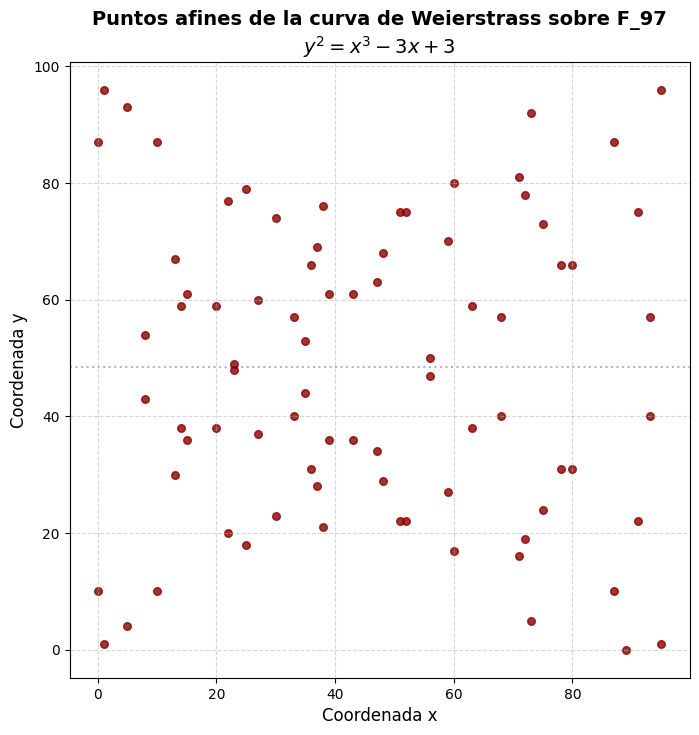

In [6]:
import matplotlib.pyplot as plt

# Parámetros de la curva de Weierstrass
p = 97
a = -3
b = 3

puntos_x = []
puntos_y = []

# Búsqueda de todos los pares (x,y) en F_97
for x in range(p):
    for y in range(p):
        
        # Comprobamos la congruencia
        izq = (y**2) % p
        der = (x**3 + a*x + b) % p
        
        if izq == der:
            puntos_x.append(x)
            puntos_y.append(y)

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.scatter(puntos_x, puntos_y, color='darkred', s=30, alpha=0.8)

plt.title('Puntos afines de la curva de Weierstrass sobre F_97\n$y^2 = x^3 - 3x + 3$', fontsize=14, fontweight='bold')
plt.xlabel(f'Coordenada x', fontsize=12)
plt.ylabel(f'Coordenada y', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(p/2, color='navy', linestyle=':', alpha=0.3)

plt.show()

En contraposición al caso anterior, analizamos ahora el comportamiento de la curva de Edwards $x^2 + y^2 \equiv 1 - 10x^2y^2 \pmod{97}$ sobre el mismo cuerpo finito.

Al realizar la búsqueda y graficar los puntos afines, comprobamos visualmente la principal ventaja criptográfica de este modelo: su **completitud**. A diferencia de Weierstrass, el elemento neutro $(0,1)$ pertenece al conjunto de puntos y se sitúa en el plano bidimensional discreto. Esta geometría cerrada es la que permite a los desarrolladores de Monero implementar una ley de suma unificada sin excepciones lógicas, garantizando tiempos de ejecución constantes y evitando vulnerabilidades de canal lateral.

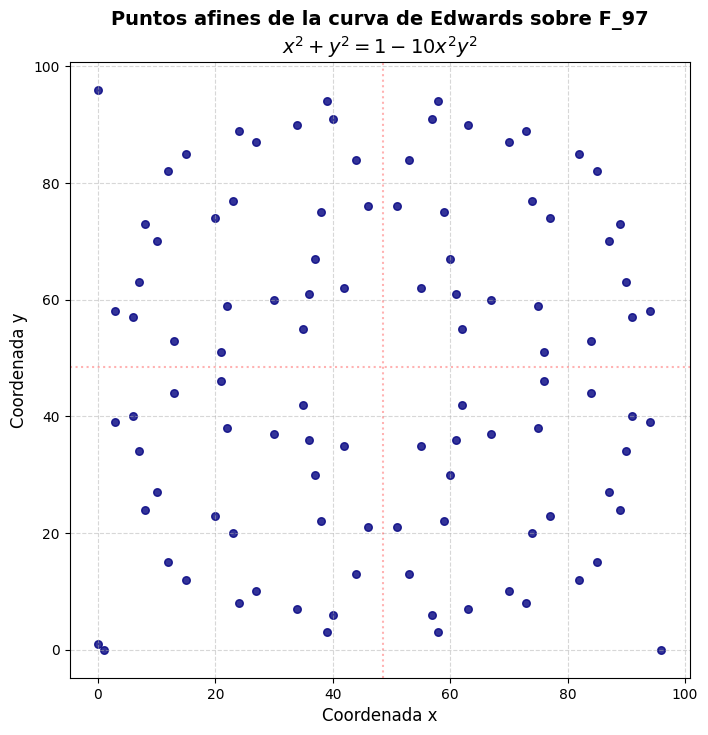

In [7]:
import matplotlib.pyplot as plt

# Parámetros de la curva de Edwards
p = 97
a = 1
d = -10

puntos_x = []
puntos_y = []

# Búsqueda de todos los pares (x,y) en F_97
for x in range(p):
    for y in range(p):
        
        # Comprobamos la congruencia
        izq = (a * x**2 + y**2) % p
        der = (1 + d * x**2 * y**2) % p
        
        if izq == der:
            puntos_x.append(x)
            puntos_y.append(y)

# Representación gráfica
plt.figure(figsize=(8, 8))
plt.scatter(puntos_x, puntos_y, color='navy', s=30, alpha=0.8)

plt.title('Puntos afines de la curva de Edwards sobre F_97\n$x^2 + y^2 = 1 - 10x^2y^2$', fontsize=14, fontweight='bold')
plt.xlabel(f'Coordenada x', fontsize=12)
plt.ylabel(f'Coordenada y', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(p/2, color='red', linestyle=':', alpha=0.3)
plt.axvline(p/2, color='red', linestyle=':', alpha=0.3)

plt.show()